In [1]:
import pycs3.gen.lc_func
import pycs3.gen.mrg
import pycs3.spl.topopt
import pycs3.regdiff.rslc
import pycs3.gen.util
import pycs3.spl.topopt
import pycs3.gen.splml
import pycs3.regdiff.multiopt
import logging
loggerformat='%(message)s'
logging.basicConfig(format=loggerformat,level=logging.INFO)

In [2]:
rdbfile = "data/trialcurves.txt"

lcs = [
    pycs3.gen.lc_func.rdbimport(rdbfile, 'A', 'mag_A', 'magerr_A', "Trial"),
    pycs3.gen.lc_func.rdbimport(rdbfile, 'B', 'mag_B', 'magerr_B', "Trial"),
    pycs3.gen.lc_func.rdbimport(rdbfile, 'C', 'mag_C', 'magerr_C', "Trial"),
    pycs3.gen.lc_func.rdbimport(rdbfile, 'D', 'mag_D', 'magerr_D', "Trial")
]

Checking header of "trialcurves.txt"...
Reading "trialcurves.txt"...
[Trial/A] with 192 points imported (0 of them masked).
Checking header of "trialcurves.txt"...
Reading "trialcurves.txt"...
[Trial/B] with 192 points imported (0 of them masked).
Checking header of "trialcurves.txt"...
Reading "trialcurves.txt"...
[Trial/C] with 192 points imported (0 of them masked).
Checking header of "trialcurves.txt"...
Reading "trialcurves.txt"...
[Trial/D] with 192 points imported (0 of them masked).


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
	[Trial/A]
192 points (total), 0 of which are masked
4 seasons (gap: >60), gap length : 164.0 +/- 33.8 days
Sampling : median 4.0, mean 4.4, max 25.1, min 0.83 days
Shifts : (0.00000,0.00000,0.00) [days, mag, flux]
Colour : red
Common properties : 
   All properties : 
Comments :
   Imported from trialcurves.txt, columns (1, 2, 3)
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


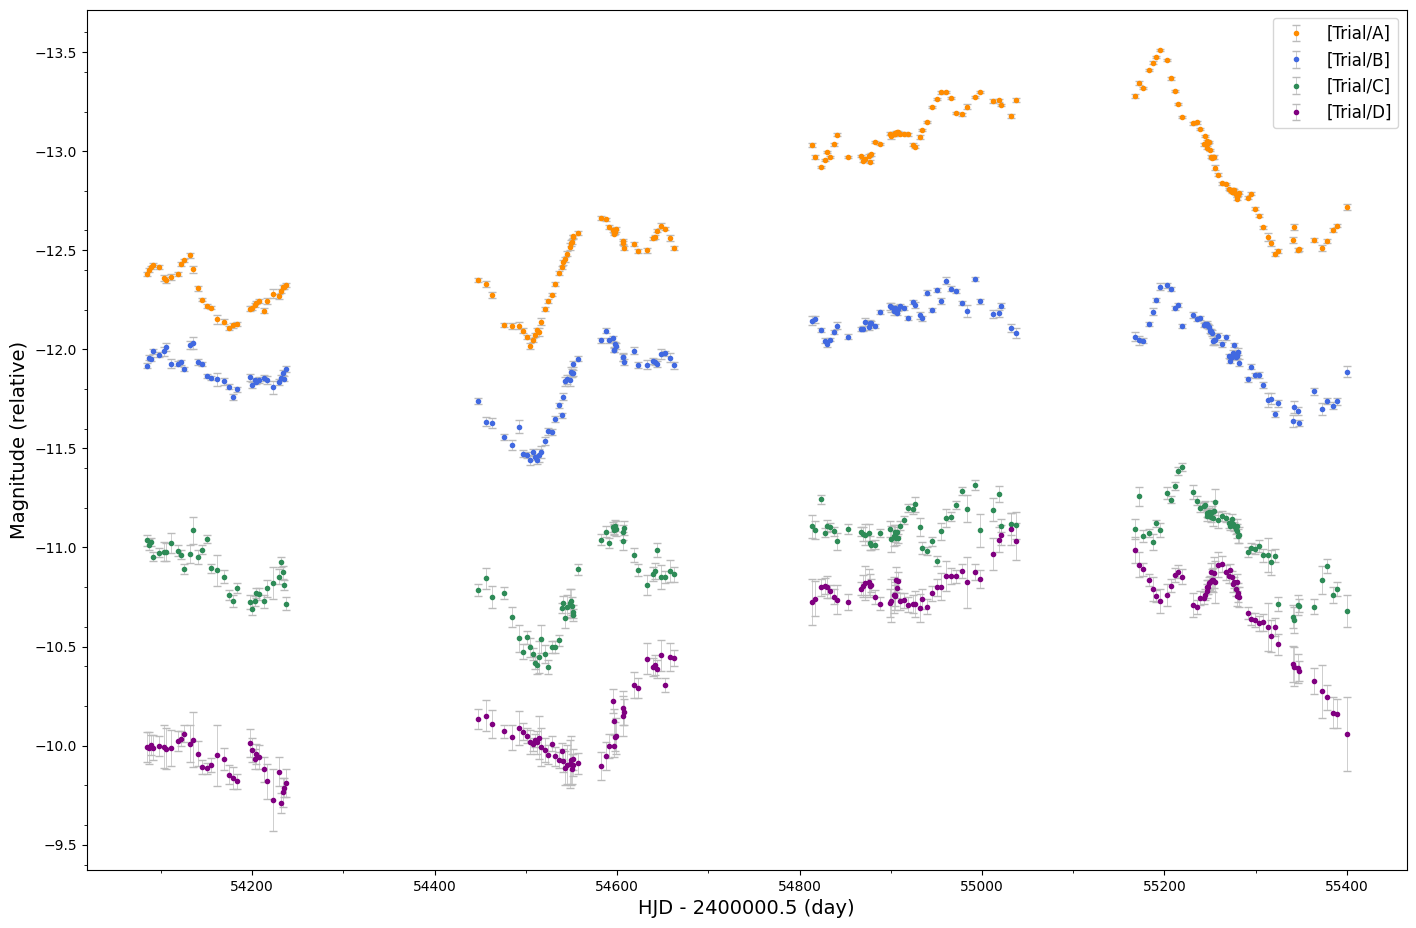

In [3]:
%matplotlib inline
print(lcs[0].longinfo())
pycs3.gen.mrg.colourise(lcs) # Gives each curve a different colour.
pycs3.gen.lc_func.display(lcs, figsize= (15,10)) 


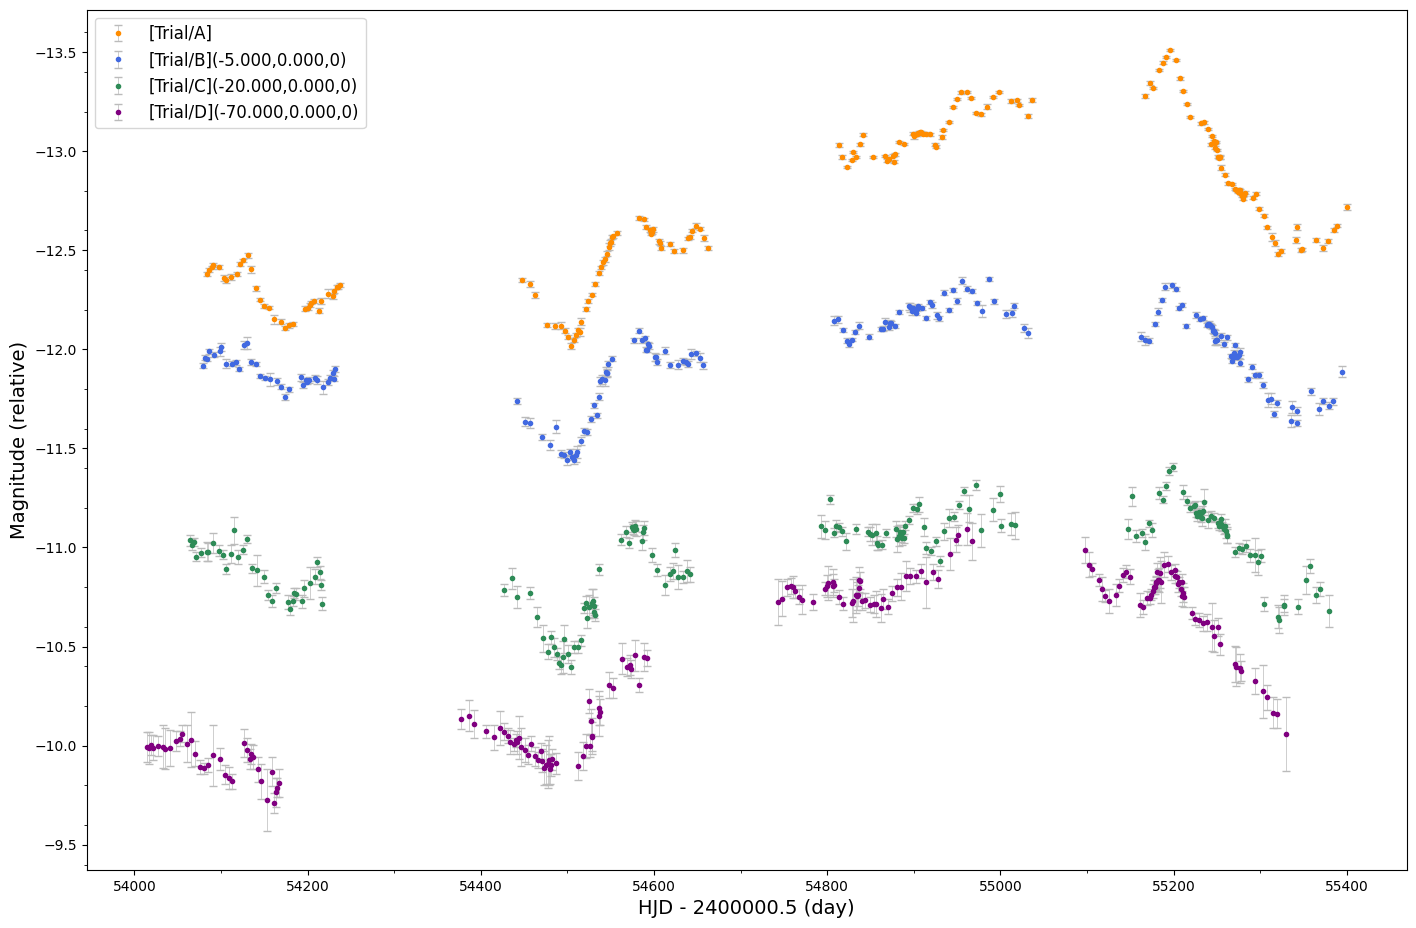

In [4]:
lcs[1].shifttime(-5.0)
lcs[2].shifttime(-20.0)
lcs[3].shifttime(-70.0)

pycs3.gen.lc_func.display(lcs, figsize= (15,10)) 

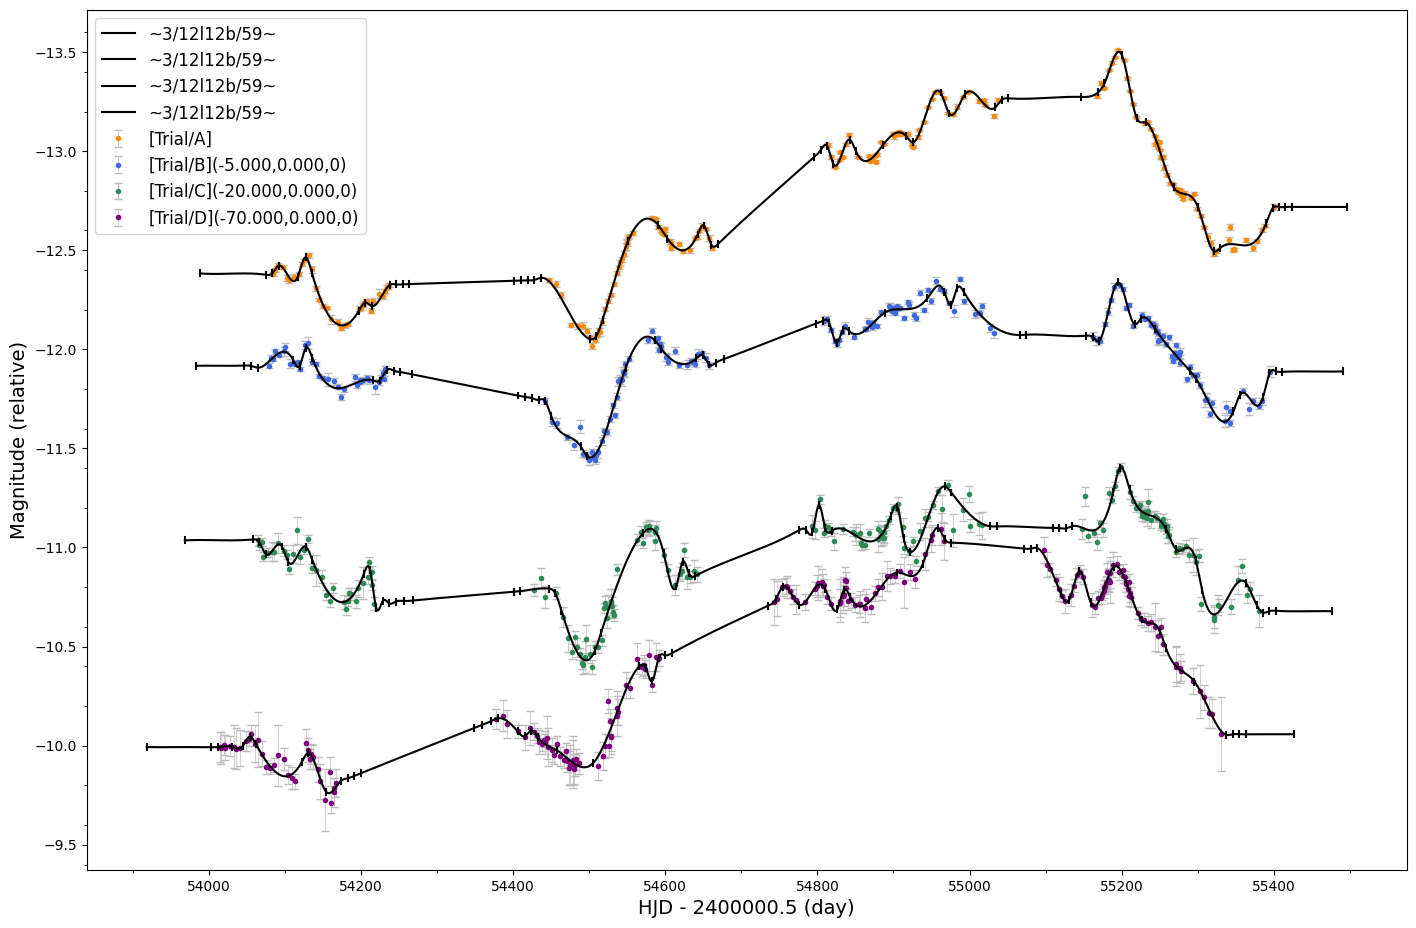

In [5]:
kn = 25 #mean spacing between the knots
splines = [] 
for lc in lcs : 
    splines.append(pycs3.spl.topopt.opt_fine([lc], knotstep=kn, bokeps=kn / 3.0, nit=10, stabext=100, shifttime=False, verbose = False))
    
pycs3.gen.lc_func.display(lcs, splines, figsize= (15,10)) 

C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\

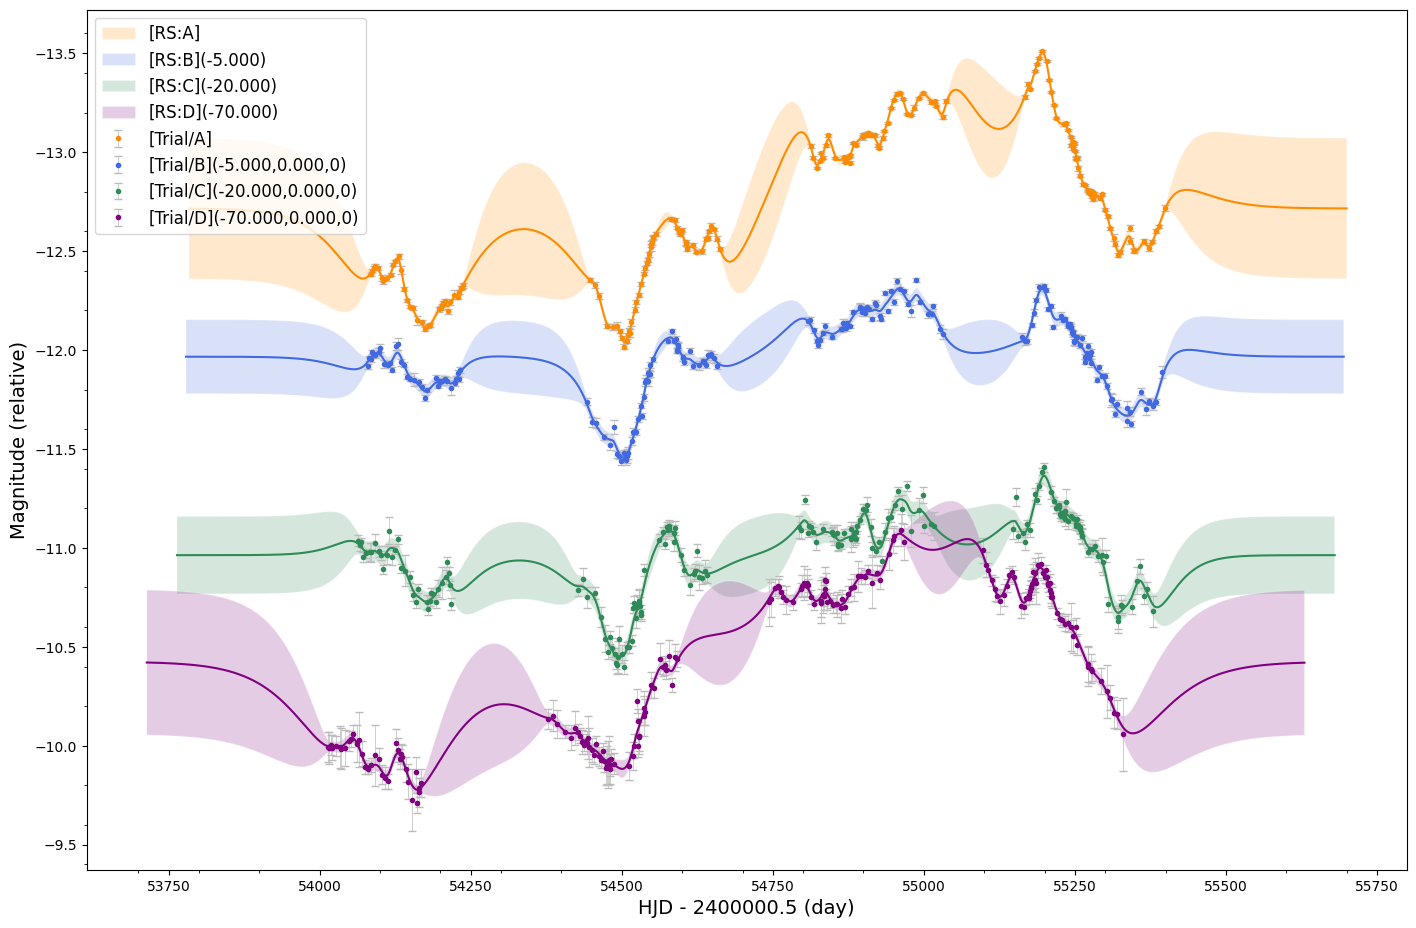

In [6]:
#Regdiff 
regdiff_param = {'pd': 2, 'covkernel': 'matern', 'pow': 1.5, 'amp': 1., 'scale': 200., 'errscale': 1.}

myrslcs = [pycs3.regdiff.rslc.factory(l, pd=regdiff_param['pd'], covkernel=regdiff_param['covkernel'],
                                    pow=regdiff_param['pow'], errscale=regdiff_param['errscale']) for l in lcs]


pycs3.gen.lc_func.display(lcs, myrslcs, figsize= (15,10) )

Starting ML optimization ...
Done !


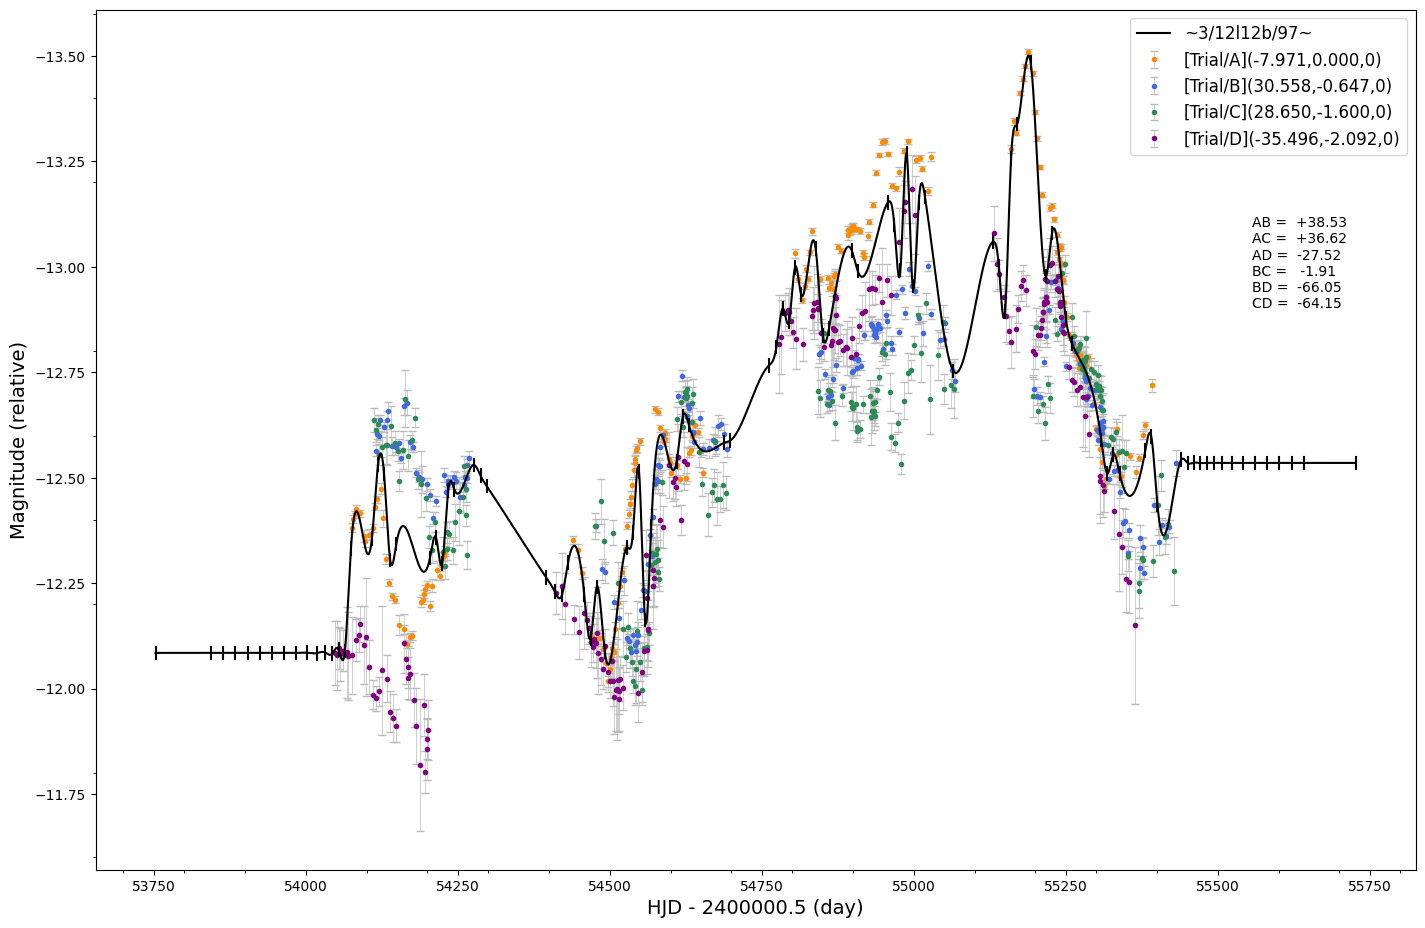

Time delays:
AB =  +38.53
AC =  +36.62
AD =  -27.52
BC =   -1.91
BD =  -66.05
CD =  -64.15


In [7]:
def spl(lcs):
    spline = pycs3.spl.topopt.opt_rough(lcs, nit=5, knotstep=30, verbose=False)
    spline = pycs3.spl.topopt.opt_fine(lcs, nit=10, knotstep=20, verbose=False)
    return spline

spline = spl(lcs)

%matplotlib inline
pycs3.gen.lc_func.display(lcs, [spline], figsize = (15,10), showdelays =True)

print ("Time delays:")
print (pycs3.gen.lc_func.getnicetimedelays(lcs, separator="\n", to_be_sorted=True))

Starting ML optimization ...
Working on the spline ML of [Trial/A](-7.971,0.000,0)|~3/u/5~|
Working on the spline ML of [Trial/B](30.558,-0.647,0)|~3/u/5~|
Working on the spline ML of [Trial/C](28.650,-1.600,0)|~3/u/5~|
Working on the spline ML of [Trial/D](-35.496,-2.092,0)|~3/u/5~|
Done !


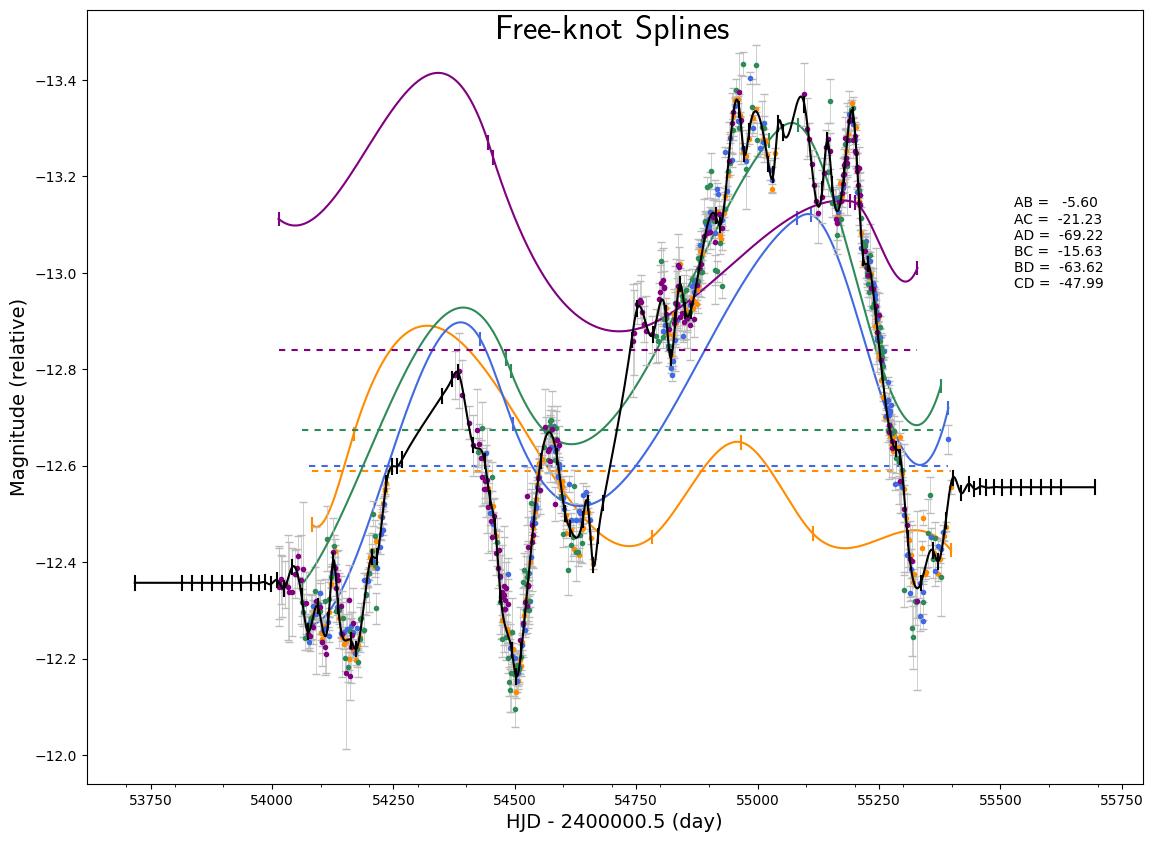

Time delays:
AB =   -5.60
AC =  -21.23
AD =  -69.22
BC =  -15.63
BD =  -63.62
CD =  -47.99


In [8]:
mlknotstep = 200

for lc in lcs : 
    pycs3.gen.splml.addtolc(lc, knotstep=mlknotstep) #we attach microlensing to the LightCurve object

spline = spl(lcs)
pycs3.gen.lc_func.display(lcs, [spline], figsize = (12,9), showdelays =True, 
                          showlegend =False, title=r"Free-knot\ Splines")
print ("Time delays:")
print (pycs3.gen.lc_func.getnicetimedelays(lcs, separator="\n", to_be_sorted=True))

In [9]:
for lc in lcs : 
    lc.resetshifts() #We reset the time shift, magnitude shift and remove microlensing
pycs3.gen.lc_func.applyshifts(lcs, [0.,0.,-10.,-60.], [0.,0.,0.,0.]) # we had an initial guess of the time delay

kwargs_reg = {'pd': 2, 'covkernel': 'matern', 'pow': 1.5, 'errscale': 1., 'amp':1., 'scale':200., 
                 'verbose': True, 'method': "weights"}

myrslcs, error_fct = pycs3.regdiff.multiopt.opt_ts(lcs, pd=kwargs_reg['pd'], covkernel=kwargs_reg['covkernel'], pow=kwargs_reg['pow'],
                           errscale=kwargs_reg['errscale'], verbose=False,
                           method="weights")
print ("Time delays:")
print (pycs3.gen.lc_func.getnicetimedelays(lcs, separator="\n", to_be_sorted=True))

C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\

Time delays:
AB =   -4.67
AC =  -20.58
AD =  -70.39
BC =  -15.91
BD =  -65.72
CD =  -49.81


<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
C:\Users\tpichard\AppData\Local\Temp\ipykernel_3172\2390433670.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$m_{%s} - m_{%s}$ \n $\mathrm{(mag)}$'%(lcs[0].object[0], lcs[1].object[-1]), fontsize = 12)
C:\Users\tpichard\AppData\Local\Temp\ipykernel_3172\2390433670.py:43: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_ylabel('$m_{%s} - m_{%s}$ \n $\mathrm{(mag)}$'%(lcs[0].object[0], lcs[2].object[-1]), fontsize = 12)
C:\Users\tpichard\AppData\Local\Temp\ipykernel_3172\2390433670.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax4.set_ylabel('$m_{%s} - m_{%s}$ \n $\mathrm{(mag)}$'%(lcs[0].object[0], lcs[3].object[-1]), fontsize = 12)
C:\Users\tpichard\a

Text(0, 0.5, '$m_{A} - m_{D}$ \n $\\mathrm{(mag)}$')

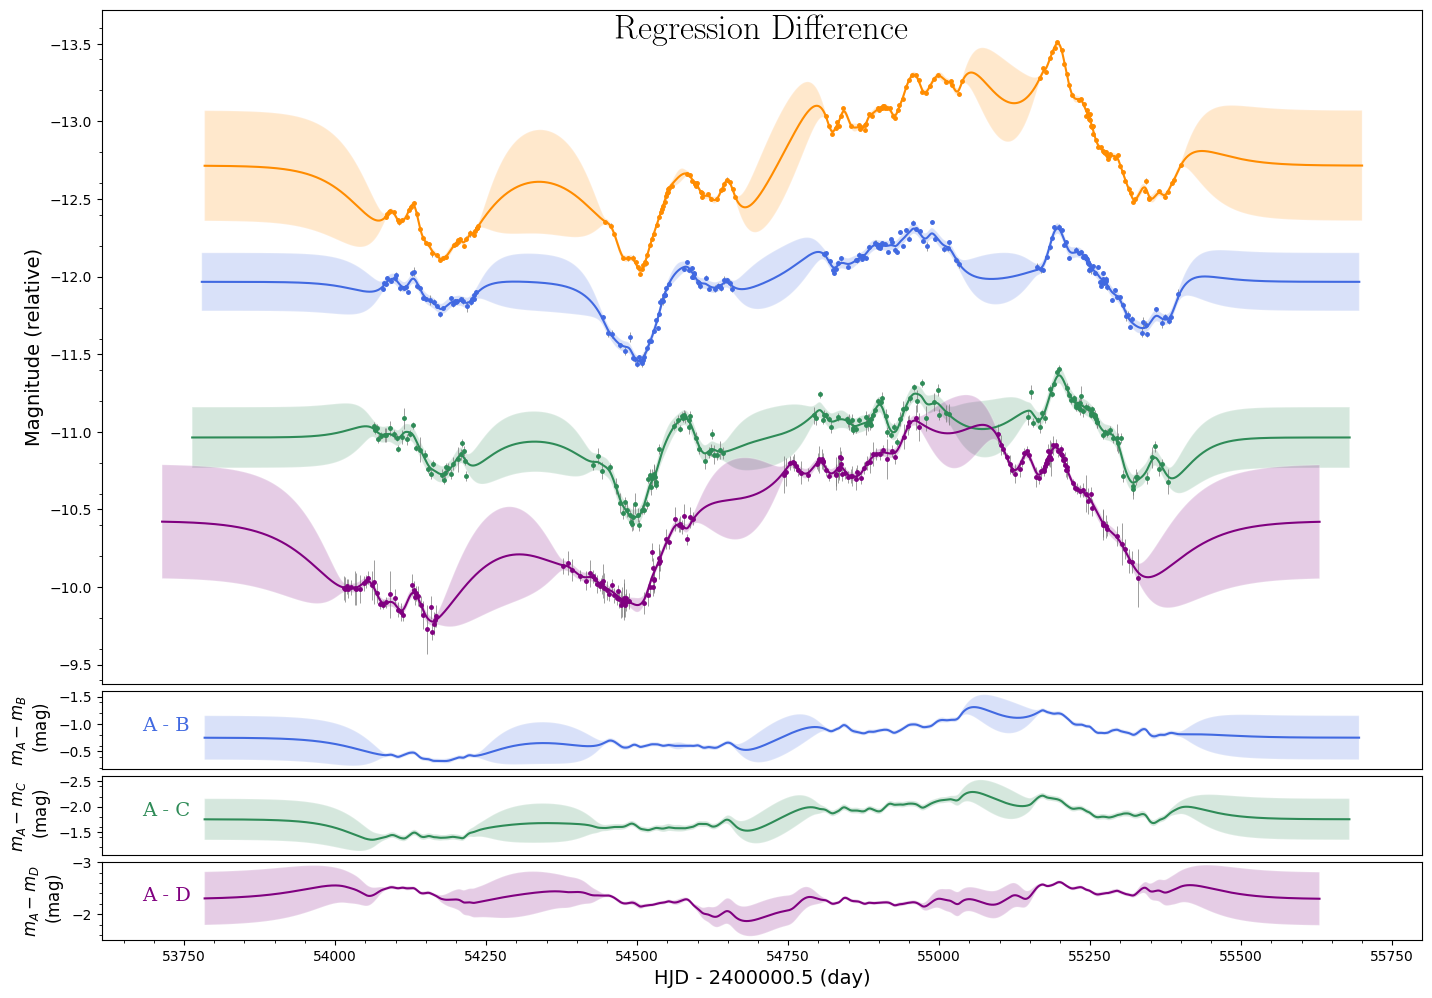

In [10]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt 

#the light curves are already shifted in time.
myrslcs = [pycs3.regdiff.rslc.factory(l, pd=kwargs_reg['pd'], covkernel=kwargs_reg['covkernel'],
                                     pow=kwargs_reg['pow'], amp=kwargs_reg['amp'], scale=kwargs_reg['scale'], errscale=kwargs_reg['errscale']) for l in lcs]
rslcs_residuals = [pycs3.regdiff.rslc.subtract(myrslcs[0],myrslcs[i]) for i in [1,2,3]]

#prepare the figure pannel : 
fig1 = plt.figure(figsize=(15, 10))
gs1 = gridspec.GridSpec(11, 2)
gs1.update(left=0.08, right=0.96, top=0.98, bottom=0.05, wspace=0.05, hspace=0.09)
ax1 = plt.subplot(gs1[:8, :])
ax2 = plt.subplot(gs1[8:9, :],sharex=ax1)
ax3 = plt.subplot(gs1[9:10, :],sharex=ax1)
ax4 = plt.subplot(gs1[10:11, :],sharex=ax1)

#colorize the residuals curves : 
for j,lc in enumerate(rslcs_residuals):
    lc.plotcolour = lcs[j+1].plotcolour

#prepare the legend for the difference curves
disptext = []
for j,lc in enumerate(rslcs_residuals) :
    ycoord = 0.5
    xcoord = 0.03
    kwargs = {"fontsize": 14, "color": lcs[j+1].plotcolour}
    txt = "A - %s"%lcs[j+1].object
    disptext.append((xcoord, ycoord, txt, kwargs))

#plot the curves, regression, and difference curves : 
pycs3.gen.lc_func.display(lcs, myrslcs, showdelays=False, showlegend=False,
                    title=r"$\mathrm{Regression\ Difference }$", filename = "screen", ax=ax1,  style="cosmograil_dr1")
pycs3.gen.lc_func.display([],[rslcs_residuals[0]], showdelays=False, showlegend=False, filename = "screen", ax=ax2, style="cosmograil_dr1", text = [disptext[0]])
pycs3.gen.lc_func.display([],[rslcs_residuals[1]], showdelays=False, showlegend=False, filename = "screen", ax=ax3, style="cosmograil_dr1", text = [disptext[1]])
pycs3.gen.lc_func.display([],[rslcs_residuals[2]], showdelays=False, showlegend=False, filename = "screen", ax=ax4, style="cosmograil_dr1", text = [disptext[2]])

#adjust the axis
ax1.get_xaxis().set_visible(False)
ax2.get_xaxis().set_visible(False)
ax2.set_ylabel('$m_{%s} - m_{%s}$ \n $\mathrm{(mag)}$'%(lcs[0].object[0], lcs[1].object[-1]), fontsize = 12)
ax3.get_xaxis().set_visible(False)
ax3.set_ylabel('$m_{%s} - m_{%s}$ \n $\mathrm{(mag)}$'%(lcs[0].object[0], lcs[2].object[-1]), fontsize = 12)
ax4.set_ylabel("Regression Difference \n Residuals (mag)", fontsize = 9)
ax4.set_ylabel('$m_{%s} - m_{%s}$ \n $\mathrm{(mag)}$'%(lcs[0].object[0], lcs[3].object[-1]), fontsize = 12)